In [2]:
import warnings
import numpy as np
from tqdm import tqdm

# Para evitar warning de divisão por zero
warnings.simplefilter(action='ignore')

def NLM(img, h, f, t):

    
    # Dimenssões espaciais da imagem
    m, n = img.shape

    # Cria imagem de saída
    filtrada = np.zeros((m, n))

    # Problema de valor de contorno: replicar bordas
    #img_n = np.pad(ruidosa, ((f, f), (f, f)), 'symmetric') # Modifiquei esta linha
    img_n = np.pad(img, ((f, f), (f, f)), 'symmetric')


    # Initializing the counter
    prog = tqdm(total=m*n, position=0, leave=True)

    # Loop principal do NLM
    for i in range(m):
        for j in range(n):

            im = i + f;   # compensar a borda adicionada artificialmente
            jn = j + f;   # compensar a borda adicionada artificialmente

            # Obtém o patch ao redor do pixel corrente
            W1 = img_n[im-f:(im+f)+1, jn-f:(jn+f)+1]

            # Calcula as bordas da janela de busca para o pixel corrente (se pixel próximo das bordas, janela de busca é menor)
            rmin = max(im-t, f);  # linha inicial
            rmax = min(im+t, m+f);  # linha final
            smin = max(jn-t, f);  # coluna inicial
            smax = min(jn+t, n+f);  # coluna final

            # Calcula média ponderada
            NL = 0      # valor do pixel corrente filtrado
            Z = 0       # constante normalizadora

            # Loop para todos os pixels da janela de busca
            for r in range(rmin, rmax):
                for s in range(smin, smax):

                    # Obtém o patch ao redor do pixel a ser comparado
                    W2 = img_n[r-f:(r+f)+1, s-f:(s+f)+1]

                    # Calcula o quadrado da distância Euclidiana
                    d2 = np.sum((W1 - W2)*(W1 - W2))

                    # Calcula a medida de similaridade
                    sij = np.exp(-d2/(h**2))

                    # Atualiza Z e NL
                    Z = Z + sij
                    NL = NL + sij*img_n[r, s]

            # Normalização do pixel filtrado
            filtrada[i, j] = NL/Z
            prog.update(1)
    return filtrada

In [ ]:
import cv2
img = cv2.imread("images/Lenna_ruidosa.png", cv2.IMREAD_GRAYSCALE)

filtrada = NLM(img,1,3,10)

### NLM versão ChatGpt

In [ ]:
import cv2
import numpy as np

def non_local_means_denoising(image, h=10, patch_size=5, search_size=17):
    """
    Implementação do Non-Local Means (NLM) para remoção de ruído.
    :param image: Imagem de entrada (numpy array, escala de cinza).
    :param h: Fator de filtragem (maior valor remove mais ruído, mas pode borrar a imagem).
    :param patch_size: Tamanho do patch (área considerada para similaridade local).
    :param search_size: Tamanho da área de busca ao redor de cada pixel.
    :return: Imagem filtrada.
    """
    
    # Converte para float para evitar problemas de precisão
    image = image.astype(np.float32)
    
    # Dimensões da imagem
    rows, cols = image.shape
    
    # Define metade dos tamanhos
    half_patch = patch_size // 2
    half_search = search_size // 2
    
    # Resultado final
    filtered_image = np.zeros_like(image)
    
    # Pad para lidar com bordas
    padded_image = cv2.copyMakeBorder(image, half_search, half_search, half_search, half_search, cv2.BORDER_REFLECT)
    
    for i in range(rows):
        for j in range(cols):
            i_p = i + half_search
            j_p = j + half_search
            
            # Extrai o patch central
            patch_center = padded_image[i_p - half_patch:i_p + half_patch + 1, j_p - half_patch:j_p + half_patch + 1]
            
            weights = []
            values = []
            
            # Percorre a janela de busca
            for m in range(-half_search, half_search + 1):
                for n in range(-half_search, half_search + 1):
                    
                    if m == 0 and n == 0:
                        continue
                    
                    # Extrai o patch vizinho
                    patch_neighbor = padded_image[i_p + m - half_patch:i_p + m + half_patch + 1, j_p + n - half_patch:j_p + n + half_patch + 1]
                    
                    # Calcula a distância Euclidiana entre os patches
                    dist = np.sum((patch_center - patch_neighbor) ** 2)
                    weight = np.exp(-dist / (h ** 2))
                    
                    weights.append(weight)
                    values.append(padded_image[i_p + m, j_p + n])
            
            # Normaliza os pesos
            weights = np.array(weights)
            weights /= np.sum(weights)
            
            # Aplica os pesos aos valores e atribui ao pixel filtrado
            filtered_image[i, j] = np.sum(weights * np.array(values))
    
    return np.clip(filtered_image, 0, 255).astype(np.uint8)

# Exemplo de uso
if __name__ == "__main__":
    img = cv2.imread("imagem_ruidosa.png", cv2.IMREAD_GRAYSCALE)
    denoised_img = non_local_means_denoising(img, h=10, patch_size=5, search_size=17)
    cv2.imwrite("imagem_denoised.jpg", denoised_img)
    cv2.imshow("Denoised Image", denoised_img)
    cv2.waitKey(0)
    cv2.destroyAllWindows()


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Função para desenhar os patches
def draw_patches(image, center, template_size, search_size):
    img_copy = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)  # Converte para BGR para destacar patches

    h, w = image.shape
    cx, cy = center

    # Define os limites do template (patch central)
    half_t = template_size // 2
    template_patch = (max(cx - half_t, 0), max(cy - half_t, 0), template_size, template_size)

    # Define os limites da janela de busca
    half_s = search_size // 2
    search_patch = (max(cx - half_s, 0), max(cy - half_s, 0), search_size, search_size)

    # Desenha o patch central em verde
    x, y, tw, th = template_patch
    cv2.rectangle(img_copy, (x, y), (x + tw, y + th), (0, 255, 0), 2)

    # Desenha a janela de busca em vermelho
    x, y, sw, sh = search_patch
    cv2.rectangle(img_copy, (x, y), (x + sw, y + sh), (0, 0, 255), 2)

    return img_copy

# Carregar a imagem em escala de cinza
image = cv2.imread("imagem_ruidosa.png", cv2.IMREAD_GRAYSCALE)

# Posição do pixel alvo (ajuste para outro pixel se quiser)
center_pixel = (100, 100)  # (x, y)

# Tamanho do template e da janela de busca
template_size = 7
search_size = 21

# Destacar os patches na imagem
image_patches = draw_patches(image, center_pixel, template_size, search_size)

# Mostrar resultado
plt.figure(figsize=(10,5))
plt.imshow(image_patches, cmap="gray")
plt.title("Visualização dos Patches do NLM")
plt.axis("off")
plt.show()


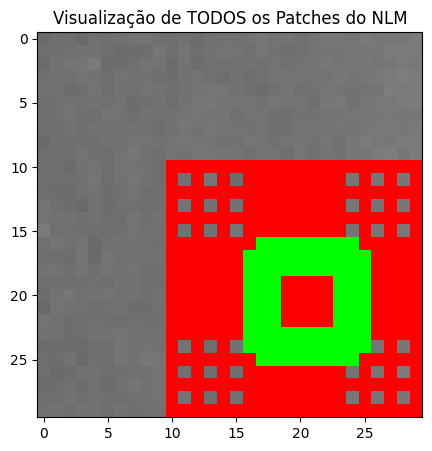

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def draw_all_patches(image, center, template_size, search_size):
    """ Destaca todos os patches usados na filtragem NLM para um pixel específico. """
    img_copy = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)  # Converte para BGR para desenhar patches

    h, w = image.shape
    cx, cy = center

    # Metade dos tamanhos
    half_t = template_size // 2
    half_s = search_size // 2

    # Limites da janela de busca
    start_x = max(cx - half_s, 0)
    start_y = max(cy - half_s, 0)
    end_x = min(cx + half_s, w - 1)
    end_y = min(cy + half_s, h - 1)

    # Desenha todos os patches dentro da janela de busca
    for x in range(start_x, end_x - template_size + 1, 2):  # Pula de 2 em 2 para melhor visualização
        for y in range(start_y, end_y - template_size + 1, 2):
            cv2.rectangle(img_copy, (x, y), (x + template_size, y + template_size), (255, 0, 0), 1)

    # Destaca o patch central em verde
    x, y = cx - half_t, cy - half_t
    cv2.rectangle(img_copy, (x, y), (x + template_size, y + template_size), (0, 255, 0), 2)

    return img_copy

# Carregar a imagem em escala de cinza
image = cv2.imread("imagem_ruidosa.png", cv2.IMREAD_GRAYSCALE)

# Posição do pixel alvo (mude para testar outros pontos)
center_pixel = (100, 100)  # (x, y)

# Tamanhos do template e da janela de busca
template_size = 7
search_size = 21

# Criar a visualização
image_patches = draw_all_patches(image, center_pixel, template_size, search_size)

# Mostrar resultado
plt.figure(figsize=(10,5))
plt.imshow(image_patches[80:110,80:110])
plt.title("Visualização de TODOS os Patches do NLM")
#plt.axis("off")
plt.show()


In [ ]:
img[0:100,0:100]